Correlation

In Lesson 2, we looked at a scatterplot of:

    area -> price

and we could visually say:

"Larger properties generally seem to have higher prices."

But that's a visual judgment.

Now we want to turn:

"It looks like they move together."

into:

"They have a Pearson correlation of r=0.72."

That number gives us a standardized way to describe the direction and strength of a linear relationship.


You started with:

One scatterplot has a tight cluster around a rising line. Another is a diffuse cloud that slopes upward. Which is stronger?

Exactly what Pearson answers.

Imagine:

Plot A
price
  │
  │             •
  │          •
  │       •
  │    •
  │ •
  └──────────────── area

Very tight around an upward line.

You might get:

r=0.95


Plot B
price
  │       •       •
  │  •
  │             •
  │    •    •
  │       •
  └──────────────── area

Still generally upward, but much more scattered.

Maybe:

r=0.45

Both are positive.

But:

|0.95|>|0.45|

Therefore the first relationship is stronger in the linear sense Pearson measures.

The sign tells the direction while the absolute value tells the strength


0.5855182454266903


<Axes: >

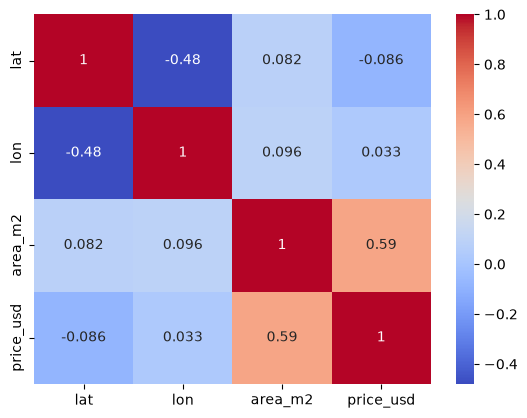

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../data/mexico-real-estate-combined-clean.csv"

data = pd.read_csv(data_path)

# lower_cut = 0.05
# upper_cut = 0.95

# data_cleaned = (data[
#     (data["price_usd"] > data["price_usd"].quantile(lower_cut))&
#     (data["price_usd"] < data["price_usd"].quantile(upper_cut))&
#     (data["area_m2"] < data["area_m2"].quantile(upper_cut))
# ])

corr_price_area = data["price_usd"].corr(data["area_m2"])

print(corr_price_area)

corr_matrix = (
    data
    .select_dtypes("number")
    .corr()
)

fig, ax = plt.subplots()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    ax=ax
)




What it means precisely:

The Pearson r of approximately 0.59 between area_m2 and price_usd tells us that roughly 35% of the variance in price can be "explained" by area (because r² = 0.59² ≈ 0.35). In plain language: if you know nothing about a property except its size, knowing the area reduces your uncertainty about the price by about 35%. The remaining 65% of price variation is explained by other factors — location, property type, condition, amenities, and factors we have not measured.

What it implies for prediction accuracy:

If you were to build the simplest possible predictive model — a straight line through the cleaned scatterplot — that model would have substantial predictive power but large individual errors. Concretely:

The model would correctly rank properties by price in about 70% of pairwise comparisons (this is related to a statistic called the concordance index).
But for any individual property, the prediction interval would be very wide — perhaps ±40,000 around the predicted value. Knowing a property is 120 m² tells you the predicted price is around 102,000, but the true price could easily be anywhere from 60,000 to 180,000.
This wide prediction interval is not a failure of the model — it is an accurate statement about how much unexplained variation exists. Area is a useful but incomplete predictor of price.
What r = 0.59 does not answer:

Is the relationship the same everywhere? A national r of 0.59 is a weighted average of all state-level relationships. Some states may have r ≈ 0.85 (size strongly predicts price), while others have r ≈ 0.10 (size barely matters). The national number conceals this variation entirely. Section 4 will reveal it.

Is the relationship causal? Correlation is not causation. The fact that larger properties cost more does not mean that adding square footage causes a property to become more valuable. Both area and price may be driven by the same underlying variable — location. In an expensive neighborhood, both larger properties and higher prices are the norm; in a cheap neighborhood, both smaller properties and lower prices are the norm. The correlation may partly reflect location sorting rather than a pure size effect.

Is the relationship linear? Pearson r assumes linearity. If the true relationship is curved — for example, if each additional square meter becomes less valuable as total size grows (diminishing returns) — then r will understate the true relationship. Section 5 will test this with the price_per_m2 feature.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../data/mexico-real-estate-combined-clean.csv"

data = pd.read_csv(data_path)

corr_price_area = data.groupby("state")[["area_m2","price_usd"]].corr().iloc[:,1].xs("area_m2", level=1).sort_values(ascending=False).head()
print(corr_price_area)




state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64


Reading the per-state correlation results

The top states (r close to 0.8 or higher) are markets where size strongly predicts price. A larger property commands a proportionally higher price with little additional influence from other factors. These tend to be markets with relatively homogeneous property types and less urban density.

The bottom states (r close to 0 or even negative) are markets where size barely explains price. In urban, dense markets — especially Mexico City — a 100 m² apartment might be worth 
250,000 in a central neighborhood. Size is swamped by location, floor, and amenities.

Near-perfect correlations (r close to 1.0 or -1.0) in some states:

⚠️ Beware of perfect correlations from small samples. A state with only 4 or 5 listings will almost always produce a correlation near 1.0 or -1.0 — not because the relationship is real, but because a straight line can be made to fit almost any 4 points. This is the same principle that makes fitting a 3rd-degree polynomial through 4 points trivially easy. Always check the sample size alongside the correlation value: data.groupby("state").size().

The broader lesson — Simpson's Paradox:

The national r = 0.59 is a weighted average of state-level correlations ranging from near-zero to 0.9+. This average does not describe any state accurately.

This is an instance of Simpson's Paradox: a trend that appears in aggregate data can reverse or disappear when you examine subgroups separately. In our case:

Nationally: moderate positive correlation (0.59)
In some states: strong positive correlation (0.8+)
In others: weak or no correlation (<0.2)
The aggregate number was not wrong — but it was fundamentally incomplete. Always examine subgroup statistics alongside aggregated ones. Never trust a national average to describe local behavior.

What to do when you find Simpson's Paradox — a practical protocol:

Discovering that a subgroup pattern differs dramatically from the aggregate result is not the end of your analysis — it is the beginning of a more important investigation. Here is the recommended protocol when you encounter it:

Step 1 — Verify the subgroup sizes. Before drawing any conclusions from subgroup correlations, compute data.groupby("state").size(). A state with only 5 listings will almost always produce a near-perfect correlation (r ≈ ±0.9) purely by chance — 5 points can be made to fit a straight line almost trivially. Discard or flag subgroup statistics where n < 20 as statistically unreliable. For formal analysis, you would use hypothesis testing (e.g., Fisher's z-test) to determine which correlations are significantly different from zero.

Step 2 — Check the direction of the paradox. There are three forms of Simpson's Paradox:

Reversal: The national correlation is positive, but some subgroup correlations are negative (or vice versa). This is the most dramatic form — the sign changes.
Attenuation: The national correlation is moderate, but subgroups show much stronger relationships. The aggregate understates the true local signal.
Amplification: Subgroups show weaker correlations than the aggregate. This is less common but can occur when groups are positioned at different points along a shared trend line (the "ecological correlation" effect).
In our housing data, we are likely seeing attenuation: the national r ≈ 0.59 is weaker than the r ≈ 0.8+ seen in some states, because the national average mixes markets where size matters a lot with markets where it barely matters.

Step 3 — Identify the confounding variable. Simpson's Paradox almost always has a cause: a third variable (the confounder) that is correlated with both the predictor (area) and the outcome (price), and that differs systematically across subgroups. In our case, location is the confounder. Urban markets (DF) have small, expensive properties; rural markets have large, cheap properties. Mixing these together creates a national average that does not describe either.

Step 4 — Report both levels. The correct response to Simpson's Paradox is not to choose one level of analysis over the other — it is to report both and explain the discrepancy. Your analysis should say: "Nationally, the area-price correlation is 0.59 [n=1,736]. However, this varies substantially by state, from r ≈ 0.05 in Distrito Federal [n=312] to r ≈ 0.82 in Yucatán [n=147]. The national average reflects differences in market composition, not a single consistent relationship."

Step 5 — Reconsider your modeling approach. If the relationship differs by group, a single global model is inappropriate. Better options include:

Stratified models: fit separate models for each major state
Interaction terms: add a state × area interaction term that allows the slope to vary by location
Mixed-effects models: estimate a shared national slope plus a per-state random deviation from that slope (more advanced, covered in later courses)

In [3]:
# correlation by property type

import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

data = pd.read_csv(data_path)

corr_by_prop = data.groupby("property_type")[["area_m2", "price_usd"]].corr().iloc[:,1].xs("area_m2", level=1).head()

print(corr_by_prop)



property_type
apartment    0.519021
house        0.719280
Name: price_usd, dtype: float64


Houses: r ≈ 0.72 — strong positive. Size is a reliable predictor of house prices.
Apartments: r ≈ 0.52 — moderate positive. Size matters, but less reliably.

Why do apartments have a weaker correlation than houses?

Think about what drives the value of each property type:

For apartments, size competes with all the other factors listed above. A 70 m² apartment with a rooftop pool in a central location might cost 3× more than an 80 m² apartment in the same city's periphery. Size explains some of the price difference but is drowned out by location and amenities.

In [4]:
# Feature Engineering: Price per Square Meter

# We have been analyzing `price_usd` (total price) as the outcome. But total price
# is *confounded* by size: a large property almost always costs more in total,
# even if it is cheaper per square meter.

# Is a 300,000 property expensive? Compared to what?


#  A 300,000 property could be a modest 150 m² house (2,000/m²) or an exclusive
# 50 m² studio (6,000/m²). Without dividing by size, you cannot compare the
# "value density" of properties


import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

data = pd.read_csv(data_path)

df = data.assign(
    price_per_m2 = lambda x:x["price_usd"]/x["area_m2"]
)

print(df.head())

  property_type             state        lat         lon  area_m2  price_usd  \
0         house  Estado de México  19.560181  -99.233528    150.0   67965.56   
1         house        Nuevo León  25.688436 -100.198807    186.0   63223.78   
2     apartment          Guerrero  16.767704  -99.764383     82.0   84298.37   
3     apartment          Guerrero  16.829782  -99.911012    150.0   94308.80   
4         house           Yucatán  21.052583  -89.538639    205.0  105191.37   

   price_per_m2  
0    453.103733  
1    339.912796  
2   1028.028902  
3    628.725333  
4    513.128634  
